In [16]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
from sklearn.datasets import load_iris
iris = load_iris()
iris
# 2. Convert to DataFrame (with the typo fixed!)
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

# 3. View the first 3 rows
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [17]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [18]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [20]:
irisDF['target'] = iris.target
irisDF['cluster']=kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()

# If you want to see the output right away, add this on the next line:
iris_result

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)
irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


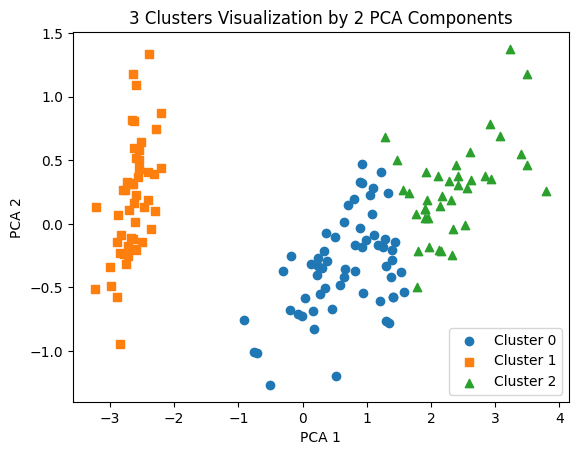

In [28]:
# 1. 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출 (오타 줄 삭제 완료)
marker0_ind = irisDF[irisDF['cluster'] == 0].index
marker1_ind = irisDF[irisDF['cluster'] == 1].index
marker2_ind = irisDF[irisDF['cluster'] == 2].index

# 2. 각 군집 레벨의 pca_x, pca_y 값 추출하여 마커 표시 (marker0_ind 오타 수정 완료)
plt.scatter(x=irisDF.loc[marker0_ind, 'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o', label='Cluster 0')
plt.scatter(x=irisDF.loc[marker1_ind, 'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s', label='Cluster 1')
plt.scatter(x=irisDF.loc[marker2_ind, 'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^', label='Cluster 2')

# 3. 라벨 및 타이틀 설정
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.legend() # 범례를 추가하면 그래프 보기가 더 편해집니다!
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

In [32]:
X, y = make_blobs (n_samples=200, n_features =2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)
#y target 값의 분포를 확인
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [33]:
import pandas as pd
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


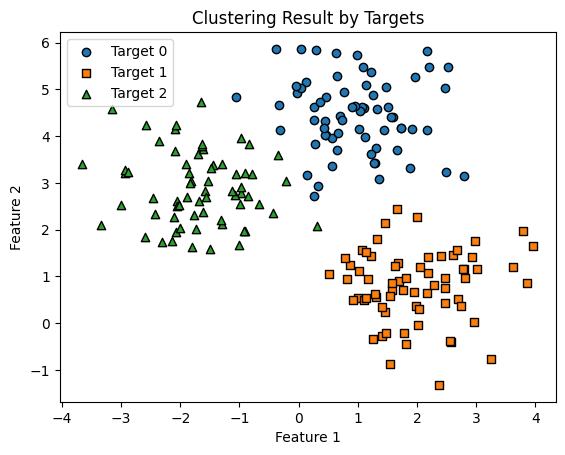

In [36]:
import numpy as np
import matplotlib.pyplot as plt

target_list = np.unique(y)
# 각 타깃별 산점도의 마커 값
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

# target_list인 [0, 1, 2]를 돌면서 마커별로 scatter plot을 생성
for target in target_list:
    # 1. '='을 '=='로 수정하고 들여쓰기(공백 4칸) 적용
    target_cluster = clusterDF[clusterDF['target'] == target]

    # 2. plt.scatter도 for문 안으로 넣어주어야 각 타깃별로 마커가 따로 그려집니다.
    #    edgecolor='k'와 marker=markers[target]의 오타도 수정했습니다.
    plt.scatter(x=target_cluster['ftr1'],
                y=target_cluster['ftr2'],
                edgecolor='k',
                marker=markers[target],
                label=f'Target {target}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clustering Result by Targets')
plt.legend()
plt.show()

In [38]:
# KMeans 객체를 이용해 X 데이터를 K-Means 클러스터링 수행
# 오타와 불필요한 특수문자($)를 모두 제거했습니다.
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

# cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
# 홀로 존재하던 'centers'를 지우고 변수에 올바르게 할당하거나 출력하도록 수정합니다.
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)


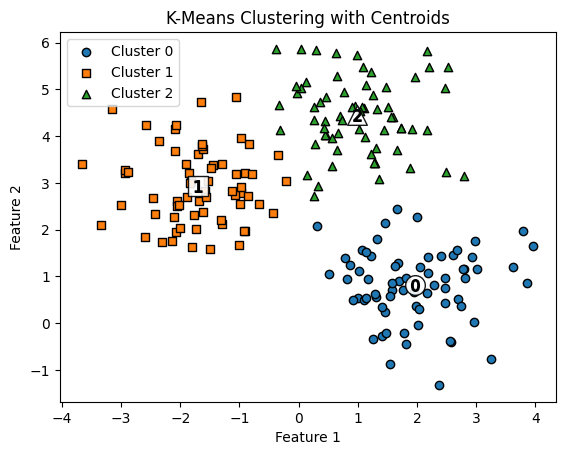

In [40]:
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행.
for label in unique_labels:
    # 1. 들여쓰기 추가 & '='를 '=='로 수정
    label_cluster = clusterDF[clusterDF['kmeans_label'] == label]
    center_x_y = centers[label]

    # 2. 들여쓰기 추가 & 'marker-markers'를 'marker=markers'로 수정 및 기호($) 제거
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                marker=markers[label], label=f'Cluster {label}')

    # 군집별 중심 위치 좌표 시각화 (흰색 바탕 큰 마커)
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white',
                alpha=0.9, edgecolor='k', marker=markers[label])

    # 군집별 중심 내부 표시 (검은색 작은 마커 또는 숫자 표시)
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',
                edgecolor='k', marker=f"${label}$")

# 그래프 마무리 설정
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

In [41]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


In [44]:
import matplotlib.pyplot as plt  # pit -> plt 오타 수정 및 줄바꿈 정리
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import scale

%matplotlib inline

iris = load_iris()
# 10번째 줄 오타(z, J, 1 등을 쉼표와 따옴표로 올바르게 수정)
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)

# init 인자와 오타(z) 수정
kmeans = KMeans(
    n_clusters=3, init="k-means++", max_iter=300, random_state=0
).fit(irisDF)
irisDF["cluster"] = kmeans.labels_

# iris 모든 개별 데이터에 실루엣 계수 값을 구함 (따옴표 및 오타 수정)
score_samples = silhouette_samples(iris.data, irisDF["cluster"])
print("silhouette_samples( ) return 값의 shape", score_samples.shape)

# irisDF 실루엣 계수 칼럼 추가
irisDF["silhouette_coeff"] = score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함.
average_score = silhouette_score(iris.data, irisDF["cluster"])
print("붓꽃 데이터 세트 Silhouette Analysis Score {0:.3f}".format(average_score))

irisDF.head(3)

silhouette_samples( ) return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [45]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


In [49]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


def visualize_silhouette(cluster_lists, X_features):
    # 입력값으로 클러스터 리스트(예: [2, 3, 4, 5])를 받아서 각 개수별 그래프 생성
    n_cols = len(cluster_lists)

    # plt.subplots로 리스트에 기재된 클러스터 수만큼의 subplots 생성
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    # 개별 클러스터 개수별로 루프 수행
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 샘플의 실루엣 값 계산
        clusterer = KMeans(n_clusters=n_cluster, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title(
            "Number of Cluster : "
            + str(n_cluster)
            + "\n"
            + "Silhouette Score :"
            + str(round(sil_avg, 3))
        )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터 라벨별로 iteration 하면서 실루엣 바 차트 그리기
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_sil_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )
            axs[ind].text(
                -0.05, y_lower + 0.5 * size_cluster_i, str(i)
            )
            y_lower = y_upper + 10

        axs[ind].axvline(
            x=sil_avg, color="red", linestyle="--"
        )  # 전체 평균 선 표시

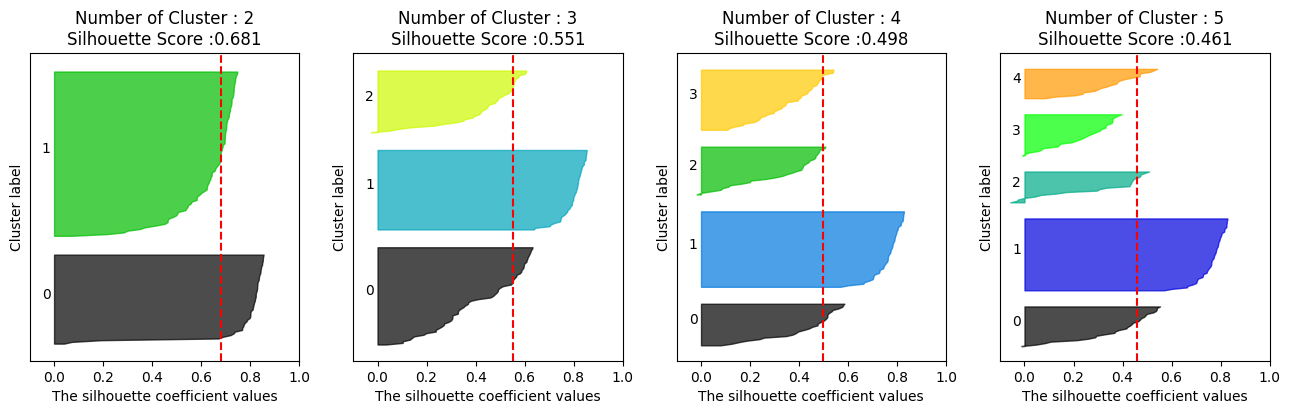

In [51]:
# 만약 X_features 데이터가 정의되지 않았다면, iris의 feature 데이터 대입
visualize_silhouette([2, 3, 4, 5], iris.data)

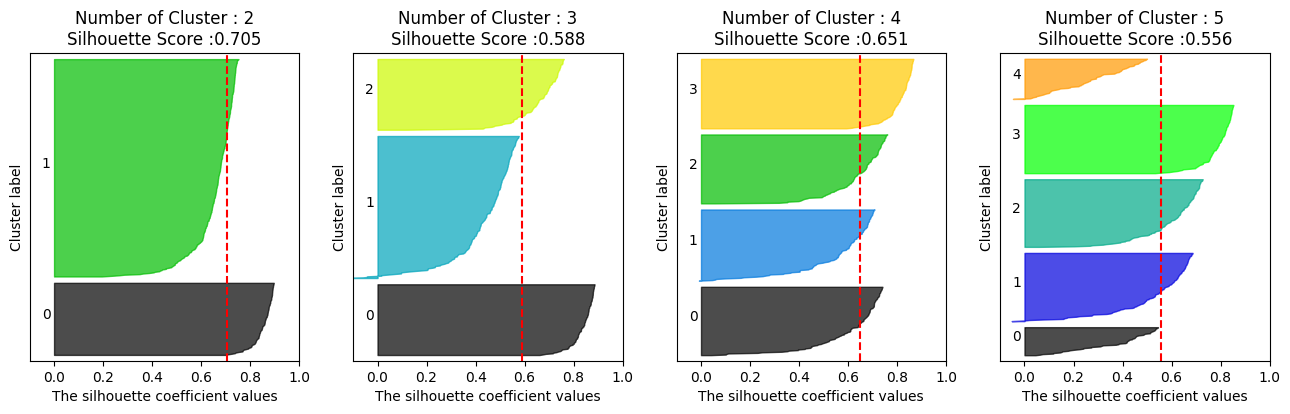

In [52]:
# make_blobs 통해 군집화를 위한 4개의 군집 중심의 500 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, center_box=(-10.0, 10.0), shuffle=True, random_state=1)
# 군집 개수가 2 , 3 , 4 , 5개일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([ 2, 3, 4, 5], X)

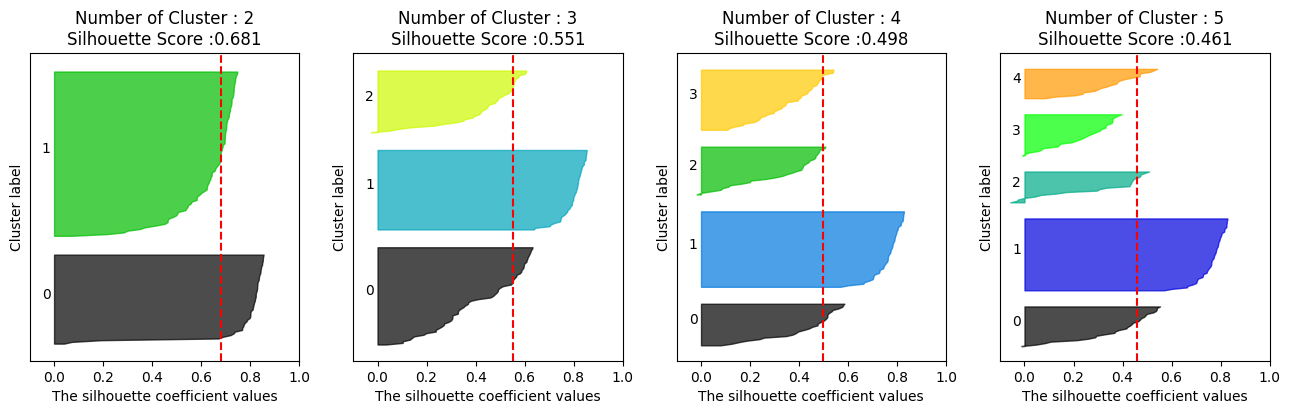

In [54]:
from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([ 2, 3, 4, 5 ], iris.data)